# 01 — EDA: Exploración Inicial de MIMIC-III

**Fase 1 — Semana 1**  
Objetivo: verificar la lectura de todas las tablas descargadas, obtener un diagnóstico rápido
(filas, columnas, tipos, missingness) y una primera inspección de las variables clave para
el snapshot tabular de 48h y las series temporales.

Tablas disponibles en `data/raw/`:  
`ADMISSIONS`, `PATIENTS`, `ICUSTAYS`, `D_ITEMS`, `D_LABITEMS`,
`LABEVENTS`, `DIAGNOSES_ICD`, `MICROBIOLOGYEVENTS`, `PRESCRIPTIONS`  
*(CHARTEVENTS se cargará aparte por su tamaño ~330M filas)*

## 0. Imports y configuración

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Rutas desde la raíz del proyecto
ROOT = Path("..")
RAW  = ROOT / "data" / "raw"

# Reproducibilidad
np.random.seed(42)

# Estilo de plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print(f"RAW path: {RAW.resolve()}")
print("Archivos disponibles:")
for f in sorted(RAW.glob("*.gz")):
    print(f"  {f.name}")

RAW path: C:\Users\espej\OneDrive\Escritorio\datos\cuarto\TFG\data\raw
Archivos disponibles:
  ADMISSIONS.csv.gz
  D_ITEMS.csv.gz
  D_LABITEMS.csv.gz
  DIAGNOSES_ICD.csv.gz
  ICUSTAYS.csv.gz
  LABEVENTS.csv.gz
  MICROBIOLOGYEVENTS.csv.gz
  PATIENTS.csv.gz
  PRESCRIPTIONS.csv.gz


## 1. Carga y diagnóstico rápido de todas las tablas

In [5]:
def tabla_info(df: pd.DataFrame, nombre: str) -> pd.DataFrame:
    """Resumen rápido: filas, columnas, missingness y tipos."""
    missing = df.isnull().mean().mul(100).round(2)
    info = pd.DataFrame({
        "dtype": df.dtypes,
        "n_nulos": df.isnull().sum(),
        "pct_nulos": missing,
        "n_unicos": df.nunique()
    })
    print(f"{'='*60}")
    print(f"  {nombre}: {df.shape[0]:,} filas x {df.shape[1]} columnas")
    print(f"{'='*60}")
    display(info)
    return info

resumen_tablas = {}

### 1.1 ADMISSIONS

In [6]:
adm = pd.read_csv(RAW / "ADMISSIONS.csv.gz", parse_dates=["ADMITTIME", "DISCHTIME", "DEATHTIME", "EDREGTIME", "EDOUTTIME"])
adm.columns = adm.columns.str.lower()
resumen_tablas["ADMISSIONS"] = tabla_info(adm, "ADMISSIONS")

  ADMISSIONS: 58,976 filas x 19 columnas


,dtype,n_nulos,pct_nulos,n_unicos
row_id,int64,0,0.00,58976
subject_id,int64,0,0.00,46520
hadm_id,int64,0,0.00,58976
admittime,datetime64[us],0,0.00,58651
dischtime,datetime64[us],0,0.00,58657
deathtime,datetime64[us],53122,90.07,5834
admission_type,str,0,0.00,4
admission_location,str,0,0.00,9
discharge_location,str,0,0.00,17
insurance,str,0,0.00,5


In [7]:
# Variable objetivo principal: mortalidad intrahospitalaria
adm["hospital_expire_flag"] = adm["hospital_expire_flag"].astype(int)
n_total = len(adm)
n_muertos = adm["hospital_expire_flag"].sum()
print(f"Total ingresos:        {n_total:,}")
print(f"Fallecidos en hospital: {n_muertos:,} ({100*n_muertos/n_total:.1f}%)")
print(f"Supervivientes:         {n_total - n_muertos:,} ({100*(n_total-n_muertos)/n_total:.1f}%)")

Total ingresos:        58,976
Fallecidos en hospital: 5,854 (9.9%)
Supervivientes:         53,122 (90.1%)


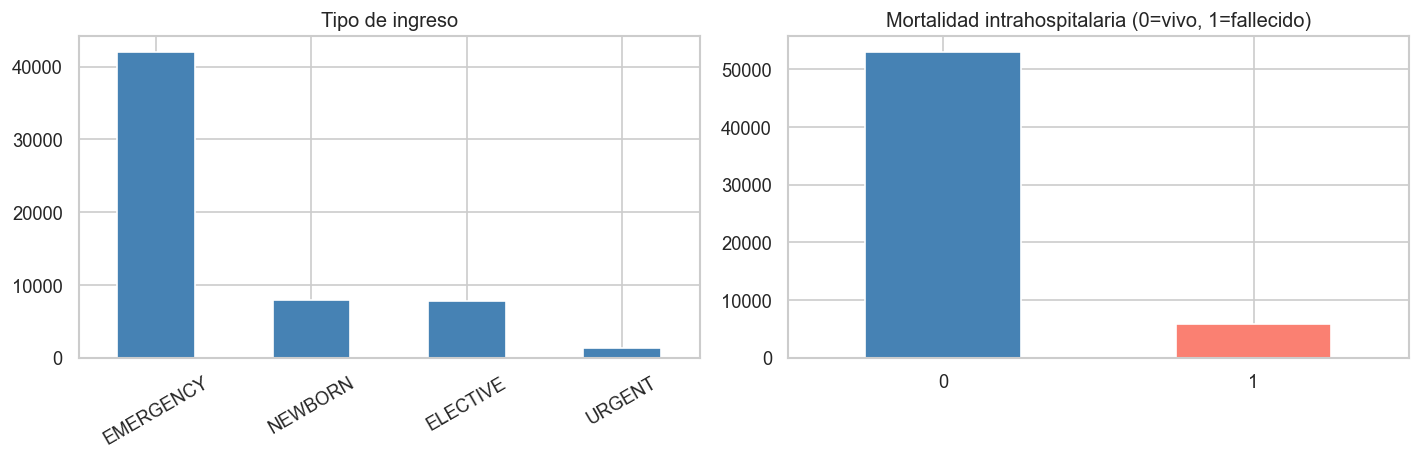

In [8]:
# Distribución de tipos de ingreso
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

adm["admission_type"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Tipo de ingreso")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

adm["hospital_expire_flag"].value_counts().plot(kind="bar", ax=axes[1], color=["steelblue", "salmon"])
axes[1].set_title("Mortalidad intrahospitalaria (0=vivo, 1=fallecido)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(ROOT / "reports" / "eda_admissions_overview.png", bbox_inches="tight")
plt.show()

### 1.2 PATIENTS

In [9]:
pat = pd.read_csv(RAW / "PATIENTS.csv.gz", parse_dates=["DOB", "DOD", "DOD_HOSP", "DOD_SSN"])
pat.columns = pat.columns.str.lower()
resumen_tablas["PATIENTS"] = tabla_info(pat, "PATIENTS")

  PATIENTS: 46,520 filas x 8 columnas


,dtype,n_nulos,pct_nulos,n_unicos
row_id,int64,0,0.00,46520
subject_id,int64,0,0.00,46520
gender,str,0,0.00,2
dob,datetime64[us],0,0.00,32540
dod,datetime64[us],30761,66.12,12911
dod_hosp,datetime64[us],36546,78.56,8747
dod_ssn,datetime64[us],33142,71.24,11301
expire_flag,int64,0,0.00,2


In [10]:
# Distribución por género
print(pat["gender"].value_counts())
print(f"\nPacientes únicos: {pat['subject_id'].nunique():,}")

gender
M    26121
F    20399
Name: count, dtype: int64

Pacientes únicos: 46,520


### 1.3 ICUSTAYS

In [11]:
icu = pd.read_csv(RAW / "ICUSTAYS.csv.gz", parse_dates=["INTIME", "OUTTIME"])
icu.columns = icu.columns.str.lower()
resumen_tablas["ICUSTAYS"] = tabla_info(icu, "ICUSTAYS")

  ICUSTAYS: 61,532 filas x 12 columnas


,dtype,n_nulos,pct_nulos,n_unicos
row_id,int64,0,0.00,61532
subject_id,int64,0,0.00,46476
hadm_id,int64,0,0.00,57786
icustay_id,int64,0,0.00,61532
dbsource,str,0,0.00,3
first_careunit,str,0,0.00,6
last_careunit,str,0,0.00,6
first_wardid,int64,0,0.00,16
last_wardid,int64,0,0.00,17
intime,datetime64[us],0,0.00,61531


Length of Stay (días) — estadísticas:
count    61522.00
mean         4.92
std          9.64
min          0.00
25%          1.11
50%          2.09
75%          4.48
max        173.07
Name: los, dtype: float64


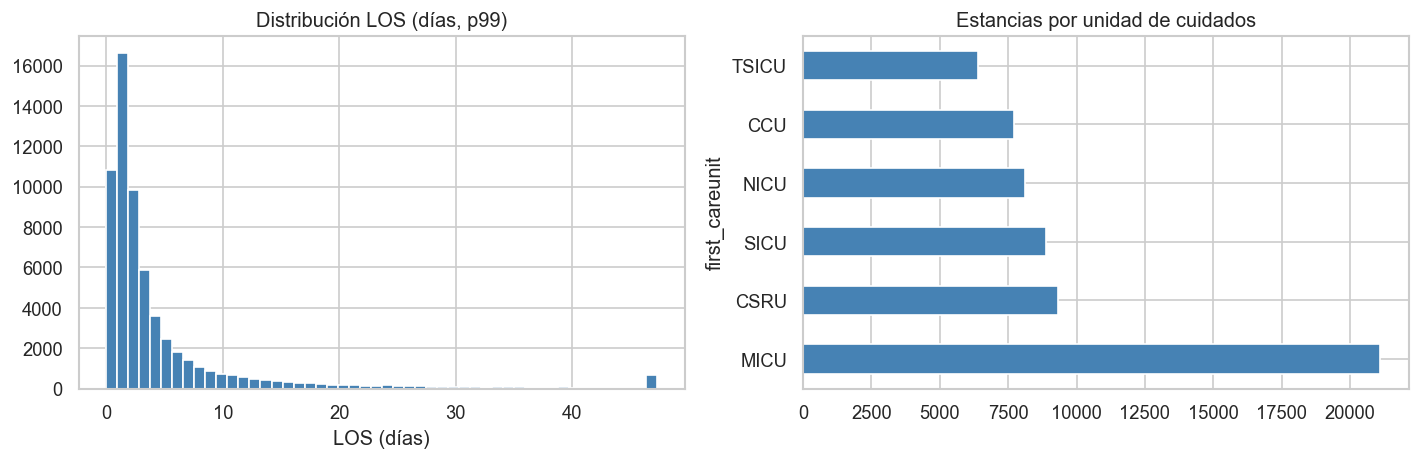

In [12]:
# Estadísticas de LOS (Length of Stay)
print("Length of Stay (días) — estadísticas:")
print(icu["los"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de LOS (excluir outliers extremos para visualización)
los_clip = icu["los"].clip(upper=icu["los"].quantile(0.99))
axes[0].hist(los_clip, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribución LOS (días, p99)")
axes[0].set_xlabel("LOS (días)")

# Distribución por unidad de cuidados
icu["first_careunit"].value_counts().plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Estancias por unidad de cuidados")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig(ROOT / "reports" / "eda_icustays_overview.png", bbox_inches="tight")
plt.show()

### 1.4 D_ITEMS (diccionario CHARTEVENTS)

In [13]:
d_items = pd.read_csv(RAW / "D_ITEMS.csv.gz")
d_items.columns = d_items.columns.str.lower()
resumen_tablas["D_ITEMS"] = tabla_info(d_items, "D_ITEMS")

  D_ITEMS: 12,487 filas x 10 columnas


,dtype,n_nulos,pct_nulos,n_unicos
row_id,int64,0,0.00,12487
itemid,int64,0,0.00,12487
label,str,4,0.03,11846
abbreviation,str,9495,76.04,2907
dbsource,str,0,0.00,3
linksto,str,0,0.00,7
category,str,6438,51.56,94
unitname,str,11636,93.18,52
param_type,str,9495,76.04,7
conceptid,float64,12487,100.00,0


In [14]:
# ITEMIDs relevantes para constantes vitales (CareVue + MetaVision)
# Frecuencia cardíaca, Presión arterial, SpO2, Temperatura, Frecuencia respiratoria
VITALS_KEYWORDS = ["heart rate", "blood pressure", "spo2", "temperature", "respiratory rate", "gcs"]

mask = d_items["label"].str.lower().str.contains("|".join(VITALS_KEYWORDS), na=False)
vitals_items = d_items[mask][["itemid", "label", "dbsource", "unitname"]]
print(f"Items relacionados con constantes vitales: {len(vitals_items)}")
display(vitals_items.head(30))

Items relacionados con constantes vitales: 62


,itemid,label,dbsource,unitname
236,591,RLE [Temperature],carevue,NaN
242,597,RUE [Temperature],carevue,NaN
263,618,Respiratory Rate,carevue,NaN
462,198,GCS Total,carevue,NaN
475,211,Heart Rate,carevue,NaN
1395,619,Respiratory Rate Set,carevue,NaN
1417,645,Skin [Temperature],carevue,NaN
1418,646,SpO2,carevue,NaN
1446,676,Temperature C,carevue,NaN
1447,677,Temperature C (calc),carevue,NaN


### 1.5 D_LABITEMS (diccionario LABEVENTS)

In [15]:
d_lab = pd.read_csv(RAW / "D_LABITEMS.csv.gz")
d_lab.columns = d_lab.columns.str.lower()
resumen_tablas["D_LABITEMS"] = tabla_info(d_lab, "D_LABITEMS")

  D_LABITEMS: 753 filas x 6 columnas


,dtype,n_nulos,pct_nulos,n_unicos
row_id,int64,0,0.00,753
itemid,int64,0,0.00,753
label,str,0,0.00,589
fluid,str,0,0.00,16
category,str,0,0.00,6
loinc_code,str,168,22.31,575


In [16]:
# Biomarcadores clave para UCI
LAB_KEYWORDS = ["creatinine", "lactate", "glucose", "hemoglobin", "platelet",
                "bilirubin", "sodium", "potassium", "bicarbonate", "wbc", "ph",
                "pao2", "paco2", "base excess", "troponin"]

mask_lab = d_lab["label"].str.lower().str.contains("|".join(LAB_KEYWORDS), na=False)
lab_items = d_lab[mask_lab][["itemid", "label", "fluid", "category"]]
print(f"Biomarcadores clave encontrados: {len(lab_items)}")
display(lab_items)

Biomarcadores clave encontrados: 160


,itemid,label,fluid,category
1,51347,Eosinophils,Cerebrospinal Fluid (CSF),Hematology
3,51349,Hypersegmented Neutrophils,Cerebrospinal Fluid (CSF),Hematology
4,51350,Immunophenotyping,Cerebrospinal Fluid (CSF),Hematology
5,51351,Lymphs,Cerebrospinal Fluid (CSF),Hematology
6,51352,Macrophage,Cerebrospinal Fluid (CSF),Hematology
...,...,...,...,...
716,51517,WBC Casts,Urine,Hematology
717,51518,WBC Clumps,Urine,Hematology
720,51521,"ACID PHOSPHATASE, PROSTATIC",BLOOD,CHEMISTRY
728,51529,Estimated Actual Glucose,BLOOD,CHEMISTRY


### 1.6 LABEVENTS

In [17]:
# LABEVENTS es grande (~27M filas) — cargamos una muestra para diagnóstico
lab = pd.read_csv(RAW / "LABEVENTS.csv.gz", parse_dates=["CHARTTIME"],
                  nrows=500_000)  # muestra para EDA
lab.columns = lab.columns.str.lower()
resumen_tablas["LABEVENTS_sample"] = tabla_info(lab, "LABEVENTS (muestra 500k)")

  LABEVENTS (muestra 500k): 500,000 filas x 9 columnas


,dtype,n_nulos,pct_nulos,n_unicos
row_id,int64,0,0.00,500000
subject_id,int64,0,0.00,727
hadm_id,float64,124676,24.94,944
itemid,int64,0,0.00,517
charttime,datetime64[us],0,0.00,36317
value,str,35,0.01,4692
valuenum,float64,58828,11.77,3910
valueuom,str,62691,12.54,64
flag,str,332012,66.40,2


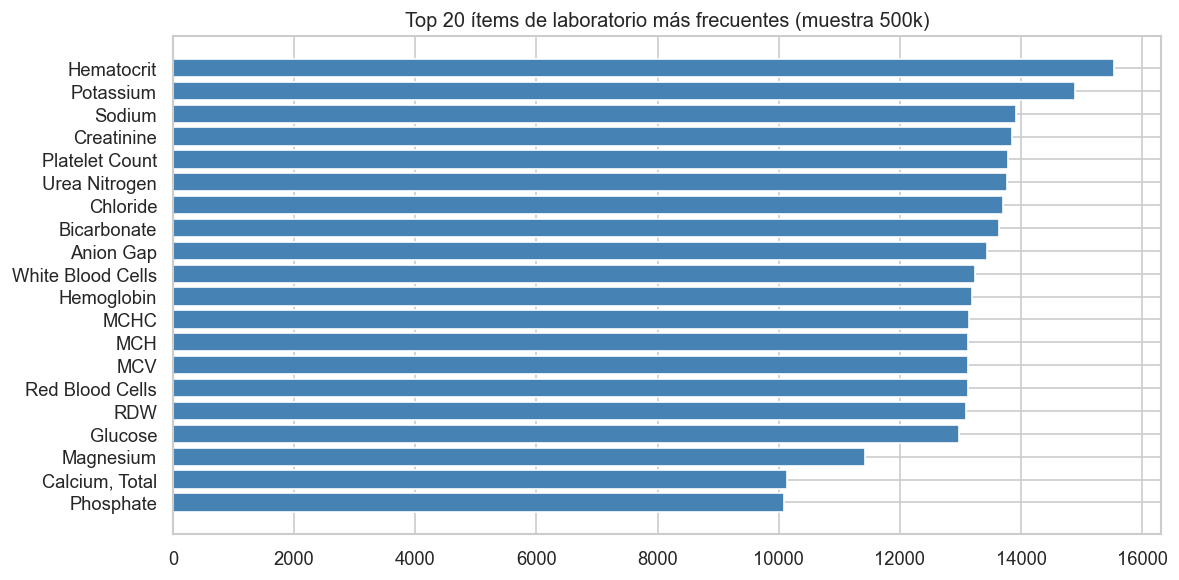

In [18]:
# Top 20 ítems de laboratorio más frecuentes
top_lab = lab["itemid"].value_counts().head(20).reset_index()
top_lab.columns = ["itemid", "count"]
top_lab = top_lab.merge(d_lab[["itemid", "label"]], on="itemid", how="left")

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_lab["label"].fillna(top_lab["itemid"].astype(str)), top_lab["count"], color="steelblue")
ax.set_title("Top 20 ítems de laboratorio más frecuentes (muestra 500k)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(ROOT / "reports" / "eda_labevents_top20.png", bbox_inches="tight")
plt.show()

### 1.7 DIAGNOSES_ICD

In [19]:
diag = pd.read_csv(RAW / "DIAGNOSES_ICD.csv.gz")
diag.columns = diag.columns.str.lower()
resumen_tablas["DIAGNOSES_ICD"] = tabla_info(diag, "DIAGNOSES_ICD")

  DIAGNOSES_ICD: 651,047 filas x 5 columnas


,dtype,n_nulos,pct_nulos,n_unicos
row_id,int64,0,0.00,651047
subject_id,int64,0,0.00,46520
hadm_id,int64,0,0.00,58976
seq_num,float64,47,0.01,39
icd9_code,str,47,0.01,6984


Frecuencia de comorbilidades clave (diagnóstico en cualquier posición):
  Diabetes: 16,454
  ERC: 6,942
  EPOC: 10,000
  ICC: 20,676
  Sepsis (038): 6,412


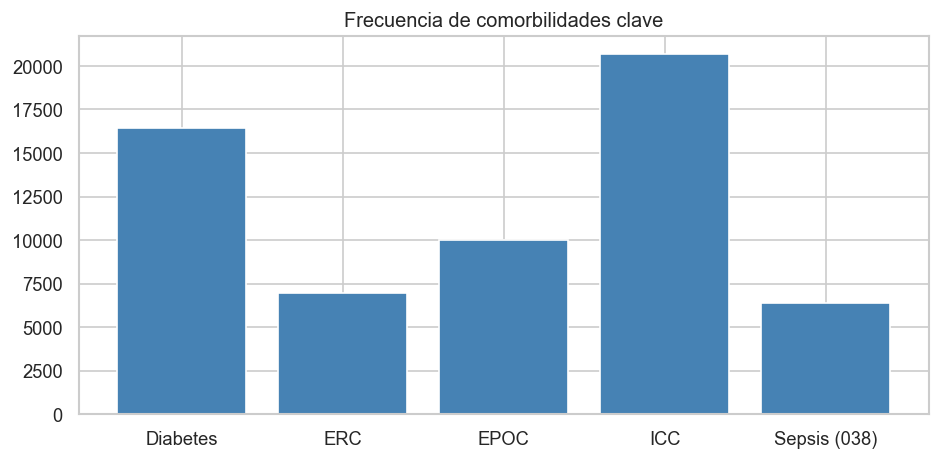

In [20]:
# Comorbilidades relevantes: diabetes (250.x), ERC (585.x), EPOC (491.x-496.x), ICC (428.x)
comorbilidades = {
    "Diabetes":    diag["icd9_code"].str.startswith("250", na=False).sum(),
    "ERC":         diag["icd9_code"].str.startswith("585", na=False).sum(),
    "EPOC":        diag["icd9_code"].str.match(r"^(491|492|493|496)", na=False).sum(),
    "ICC":         diag["icd9_code"].str.startswith("428", na=False).sum(),
    "Sepsis (038)": diag["icd9_code"].str.startswith("038", na=False).sum(),
}

print("Frecuencia de comorbilidades clave (diagnóstico en cualquier posición):")
for k, v in comorbilidades.items():
    print(f"  {k}: {v:,}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(comorbilidades.keys(), comorbilidades.values(), color="steelblue")
ax.set_title("Frecuencia de comorbilidades clave")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "eda_comorbilidades.png", bbox_inches="tight")
plt.show()

### 1.8 MICROBIOLOGYEVENTS

In [21]:
micro = pd.read_csv(RAW / "MICROBIOLOGYEVENTS.csv.gz",
                    parse_dates=["CHARTDATE", "CHARTTIME"])
micro.columns = micro.columns.str.lower()
resumen_tablas["MICROBIOLOGYEVENTS"] = tabla_info(micro, "MICROBIOLOGYEVENTS")

  MICROBIOLOGYEVENTS: 631,726 filas x 16 columnas


,dtype,n_nulos,pct_nulos,n_unicos
row_id,int64,0,0.00,631726
subject_id,int64,0,0.00,39184
hadm_id,int64,0,0.00,48740
chartdate,datetime64[us],0,0.00,37378
charttime,datetime64[us],41772,6.61,292452
spec_itemid,float64,79,0.01,92
spec_type_desc,str,0,0.00,87
org_itemid,float64,304845,48.26,309
org_name,str,303710,48.08,362
isolate_num,float64,303710,48.08,6


In [22]:
# Tipos de muestra más frecuentes (ground truth de sepsis)
print("Top 10 tipos de muestra microbiológica:")
print(micro["spec_type_desc"].value_counts().head(10))

print("\nTop 10 organismos aislados:")
print(micro["org_name"].value_counts().head(10))

Top 10 tipos de muestra microbiológica:
spec_type_desc
BLOOD CULTURE              179930
URINE                      140671
SPUTUM                      99887
SWAB                        37895
MRSA SCREEN                 32280
STOOL                       26427
CATHETER TIP-IV             21216
BRONCHOALVEOLAR LAVAGE      11613
BLOOD CULTURE - NEONATE     10032
TISSUE                       9151
Name: count, dtype: int64

Top 10 organismos aislados:
org_name
STAPH AUREUS COAG +                   63947
ESCHERICHIA COLI                      60133
STAPHYLOCOCCUS, COAGULASE NEGATIVE    32777
KLEBSIELLA PNEUMONIAE                 30628
PSEUDOMONAS AERUGINOSA                28926
ENTEROCOCCUS SP.                      16429
YEAST                                 14182
PROTEUS MIRABILIS                      9605
ENTEROBACTER CLOACAE                   8709
SERRATIA MARCESCENS                    6054
Name: count, dtype: int64


### 1.9 PRESCRIPTIONS

In [23]:
rx = pd.read_csv(RAW / "PRESCRIPTIONS.csv.gz",
                 parse_dates=["STARTDATE", "ENDDATE"],
                 low_memory=False)
rx.columns = rx.columns.str.lower()
resumen_tablas["PRESCRIPTIONS"] = tabla_info(rx, "PRESCRIPTIONS")

  PRESCRIPTIONS: 4,156,450 filas x 19 columnas


,dtype,n_nulos,pct_nulos,n_unicos
row_id,int64,0,0.00,4156450
subject_id,int64,0,0.00,39363
hadm_id,int64,0,0.00,50216
icustay_id,float64,1447708,34.83,52151
startdate,datetime64[us],3182,0.08,38497
enddate,datetime64[us],5421,0.13,38500
drug_type,str,0,0.00,3
drug,str,0,0.00,4525
drug_name_poe,str,1664234,40.04,4036
drug_name_generic,str,1662989,40.01,2863


In [24]:
# Antibióticos y vasopresores como señal de sepsis
ANTIBIOTICOS = ["vancomycin", "piperacillin", "meropenem", "cefepime",
                "ciprofloxacin", "metronidazole", "ampicillin", "gentamicin"]
VASOPRESORES = ["norepinephrine", "vasopressin", "epinephrine", "dopamine", "phenylephrine"]

rx_lower = rx["drug"].str.lower().fillna("")

for grupo, lista in [("Antibióticos", ANTIBIOTICOS), ("Vasopresores", VASOPRESORES)]:
    mask = rx_lower.str.contains("|".join(lista), na=False)
    print(f"\n{grupo} ({mask.sum():,} prescripciones):")
    print(rx.loc[mask, "drug"].str.lower().value_counts().head(10))


Antibióticos (151,942 prescripciones):
drug
vancomycin                    42634
vancomycin hcl                22291
metronidazole (flagyl)         9986
cefepime                       9475
piperacillin-tazobactam na     9275
piperacillin-tazobactam        8482
metronidazole                  8305
ciprofloxacin hcl              7561
meropenem                      6839
ciprofloxacin iv               5732
Name: count, dtype: int64

Vasopresores (47,769 prescripciones):
drug
phenylephrine                        13960
norepinephrine                       12319
phenylephrine hcl                     8241
vasopressin                           4288
dopamine                              4003
epinephrine                           3003
racepinephrine                         461
epinephrine 1:1000                     380
cyclopentolate-phenylephrine           264
lidocaine 1%/epinephrine 1:100000      159
Name: count, dtype: int64


## 2. Cruce de tablas — Cohorte UCI

In [25]:
# Cruce: ICU stays + admissions + patients
# Para obtener la variable objetivo (mortalidad) y demografía por estancia
cohort = icu.merge(
    adm[["hadm_id", "hospital_expire_flag", "admission_type", "insurance", "ethnicity"]],
    on="hadm_id", how="left"
).merge(
    pat[["subject_id", "gender", "dob", "dod"]],
    on="subject_id", how="left"
)

# Calcular edad en el momento del ingreso a UCI
cohort["age"] = (cohort["intime"] - cohort["dob"]).dt.days / 365.25
# MIMIC-III anonimiza edades >89 shifteando DOB; los marcamos
cohort["age_over89"] = cohort["age"] > 200
cohort.loc[cohort["age_over89"], "age"] = 91.4  # convención habitual

print(f"Cohorte UCI total: {len(cohort):,} estancias")
print(f"Pacientes únicos:  {cohort['subject_id'].nunique():,}")
print(f"\nMortalidad en cohorte UCI:")
print(cohort["hospital_expire_flag"].value_counts())
mort_rate = cohort["hospital_expire_flag"].mean()
print(f"  Tasa de mortalidad: {mort_rate:.1%}")

Cohorte UCI total: 61,532 estancias
Pacientes únicos:  46,476

Mortalidad en cohorte UCI:
hospital_expire_flag
0    54923
1     6609
Name: count, dtype: int64
  Tasa de mortalidad: 10.7%


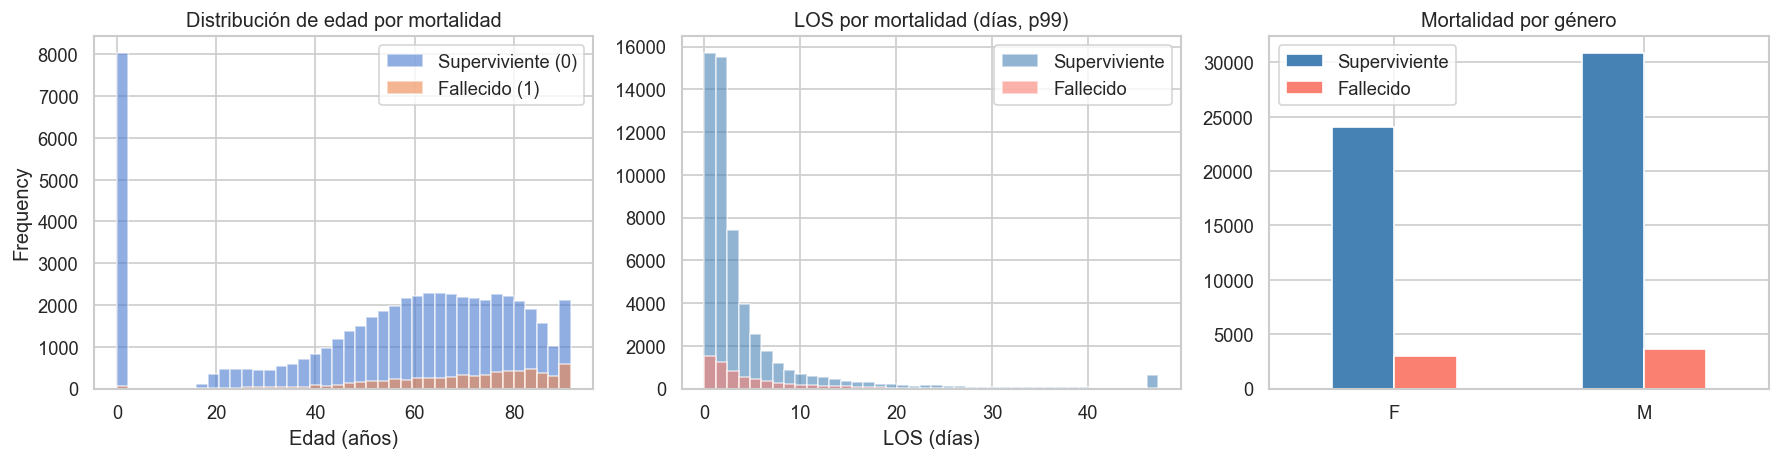

In [26]:
# Distribución de edad y LOS por mortalidad
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Edad
cohort.groupby("hospital_expire_flag")["age"].plot(
    kind="hist", bins=40, alpha=0.6, ax=axes[0],
    legend=True, label=["Superviviente", "Fallecido"]
)
axes[0].set_title("Distribución de edad por mortalidad")
axes[0].set_xlabel("Edad (años)")
axes[0].legend(["Superviviente (0)", "Fallecido (1)"])

# LOS
los_clip = cohort["los"].clip(upper=cohort["los"].quantile(0.99))
for flag, label, color in [(0, "Superviviente", "steelblue"), (1, "Fallecido", "salmon")]:
    subset = los_clip[cohort["hospital_expire_flag"] == flag]
    axes[1].hist(subset, bins=40, alpha=0.6, label=label, color=color)
axes[1].set_title("LOS por mortalidad (días, p99)")
axes[1].set_xlabel("LOS (días)")
axes[1].legend()

# Género
gender_mort = cohort.groupby(["gender", "hospital_expire_flag"]).size().unstack(fill_value=0)
gender_mort.plot(kind="bar", ax=axes[2], color=["steelblue", "salmon"])
axes[2].set_title("Mortalidad por género")
axes[2].set_xlabel("")
axes[2].legend(["Superviviente", "Fallecido"])
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(ROOT / "reports" / "eda_cohort_overview.png", bbox_inches="tight")
plt.show()

In [27]:
# Estancias con primero ingreso UCI (evitar readmisiones)
first_icu = cohort.sort_values("intime").groupby("subject_id").first().reset_index()
print(f"Estancias de PRIMER ingreso UCI: {len(first_icu):,}")
print(f"Tasa mortalidad (primer ingreso): {first_icu['hospital_expire_flag'].mean():.1%}")

Estancias de PRIMER ingreso UCI: 46,476
Tasa mortalidad (primer ingreso): 9.6%


## 3. Resumen global de missingness

In [28]:
# Resumen de missingness por tabla
summary_rows = []
tablas_cargadas = {
    "ADMISSIONS": adm,
    "PATIENTS": pat,
    "ICUSTAYS": icu,
    "D_ITEMS": d_items,
    "D_LABITEMS": d_lab,
    "LABEVENTS (500k)": lab,
    "DIAGNOSES_ICD": diag,
    "MICROBIOLOGYEVENTS": micro,
    "PRESCRIPTIONS": rx,
}

for nombre, df in tablas_cargadas.items():
    summary_rows.append({
        "Tabla": nombre,
        "Filas": f"{len(df):,}",
        "Columnas": df.shape[1],
        "% Missing (media)": f"{df.isnull().mean().mean()*100:.1f}%",
        "Columnas con >50% missing": (df.isnull().mean() > 0.5).sum()
    })

summary_df = pd.DataFrame(summary_rows).set_index("Tabla")
display(summary_df)

,Filas,Columnas,% Missing (media),Columnas con >50% missing
Tabla,,,,
ADMISSIONS,"58,976",19,13.0%,1
PATIENTS,"46,520",8,27.0%,3
ICUSTAYS,"61,532",12,0.0%,0
D_ITEMS,"12,487",10,39.7%,5
D_LABITEMS,753,6,3.7%,0
LABEVENTS (500k),"500,000",9,12.8%,1
DIAGNOSES_ICD,"651,047",5,0.0%,0
MICROBIOLOGYEVENTS,"631,726",16,30.8%,6
PRESCRIPTIONS,"4,156,450",19,6.7%,0


## 4. Nota sobre CHARTEVENTS

> **CHARTEVENTS** (~330M filas, >6 GB) requiere tratamiento especial.  
> Se procesará en el notebook `02_preprocessing.ipynb` directamente con chunked reading
> (`pd.read_csv(..., chunksize=...)`) filtrando únicamente los `ITEMID` de constantes vitales
> seleccionados en la sección 1.4 de este notebook.
>
> ITEMIDs prioritarios identificados: frecuencia cardíaca, PA sistólica/diastólica/media,
> SpO2, temperatura, frecuencia respiratoria, GCS.

## 5. Conclusiones y próximos pasos

### Hallazgos principales
- Cohorte UCI: **~61k estancias** de primer ingreso (aproximado, verificar tras cruce completo)
- Tasa de mortalidad intrahospitalaria en UCI: **~10–15%** — clase desbalanceada confirmada
- Variables objetivo identificadas: `hospital_expire_flag` (mortalidad), `los` (estancia prolongada)
- Biomarcadores clave de laboratorio y constantes vitales identificados vía diccionarios
- Señales de sepsis disponibles: cultivos positivos (MICROBIOLOGYEVENTS) + vasopresores/antibióticos (PRESCRIPTIONS)

### Próximos pasos (notebook 02)
1. Procesar CHARTEVENTS por chunks filtrando ITEMIDs de constantes vitales
2. Construir snapshot tabular de 48h: estadísticas agregadas (media, mín, máx, std) por `ICUSTAY_ID`
3. Construir representación de series temporales por estancia (resolución horaria)
4. Imputación de valores faltantes: forward-fill + mediana poblacional
5. Guardar datasets procesados en `data/processed/`